# Exploratory Data Analysis

This notebook joins the menu data with the daily statistics at the correct grain, then explores the merged dataset.

## Join strategy

- `menu_data.email` behaves like a `dou_code` key rather than a personal email.
- `statistics_dataa` is at restaurant level, so several rows can exist for the same `dou_code + date`.
- `menu_data` is effectively one daily menu per `dou_code + date`, repeated across menu items.
- Because of that, the safe join is:
  1. clean and normalize the menu dates,
  2. join the  statistics back to the menu  table.


In [106]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('ggplot')

In [107]:
menu_data       = pd.read_excel('../data/raw/Menu_20260411_anonymized.xlsx')
statistics_dataa = pd.read_excel('../data/raw/Statistics_per_day_20260410_anonymized.xlsx')
client_data     = pd.read_excel('../data/raw/Statistics_per_day_type_client_20260410_anonymized.xlsx')

print('menu_data      :', menu_data.shape)
print('statistics_data:', statistics_dataa.shape)
print('client_data    :', client_data.shape)

print("\nmenu columns      :", menu_data.columns.tolist())
print("statistics columns:", statistics_dataa.columns.tolist())
print("client columns    :", client_data.columns.tolist())

menu_data      : (570803, 7)
statistics_data: (249837, 9)
client_data    : (250249, 21)

menu columns      : ['meal', 'quantity', 'date', 'meal_type_id', 'name', 'email', 'id']
statistics columns: ['create_date', 'resto_name', 'dou_code', 'id', 'id_pro', 'count', 'breakfast', 'launch', 'dinner']
client columns    : ['create_date', 'resto_name', 'dou_code', 'id', 'id_pro', 'count', 'breakfast', 'launch', 'dinner', 'breakfast_etudiant', 'launch_etudiant', 'dinner_etudiant', 'breakfast_employe', 'launch_employe', 'dinner_employe', 'breakfast_doctorant', 'launch_doctorant', 'dinner_doctorant', 'breakfast_para_medical', 'launch_para_medical', 'dinner_para_medical']


In [108]:
YEAR_FIX_MAP = {
    '0002': 2023, '0004': 2024, '0006': 2026, '0020': 2024,
    '0023': 2023, '0024': 2024, '0025': 2025, '0026': 2026,
    '0202': 2024, '0203': 2024, '0204': 2024, '0205': 2025,
    '0206': 2026, '0224': 2024, '0225': 2025, '0242': 2024,
}

MEAL_TYPE_LABELS = {1: 'breakfast', 2: 'lunch', 3: 'dinner'}

palette = {'breakfast': '#f4a261', 'lunch': '#2a9d8f', 'dinner': '#264653'}

In [109]:
def repair_menu_date(value):
    if pd.isna(value):
        return pd.NaT
    if isinstance(value, pd.Timestamp):
        return value.normalize()
    parsed = pd.to_datetime(value, errors='coerce')
    if pd.notna(parsed) and 2023 <= parsed.year <= 2026:
        return parsed.normalize()
    text = str(value).strip()
    match = re.fullmatch(r'(\d{4})-(\d{2})-(\d{2})', text)
    if not match:
        return pd.NaT
    year_token, month, day = match.groups()
    fixed_year = YEAR_FIX_MAP.get(year_token)
    if fixed_year is None:
        embedded = [yy for yy in ('23', '24', '25', '26') if yy in year_token]
        if len(embedded) == 1:
            fixed_year = int(f'20{embedded[0]}')
    if fixed_year is None:
        return pd.NaT
    return pd.Timestamp(f'{fixed_year}-{month}-{day}')


menu_clean = (
    menu_data.assign(
        dou_code    = pd.to_numeric(menu_data['email'], errors='coerce').astype('Int64'),
        date        = menu_data['date'].apply(repair_menu_date),
        meal        = menu_data['meal'].astype(str).str.strip(),
        meal_type_id= pd.to_numeric(menu_data['meal_type_id'], errors='coerce').astype('Int64'),
    )
    .dropna(subset=['dou_code', 'date'])
)

statistics_clean = statistics_dataa.assign(
    dou_code = pd.to_numeric(statistics_dataa['dou_code'], errors='coerce').astype('Int64'),
    date     = pd.to_datetime(statistics_dataa['create_date'], errors='coerce').dt.normalize(),
)

client_clean = client_data.assign(
    dou_code = pd.to_numeric(client_data['dou_code'], errors='coerce').astype('Int64'),
    date     = pd.to_datetime(client_data['create_date'], errors='coerce').dt.normalize(),
)

print('Unresolved menu dates after repair:', menu_clean['date'].isna().sum())
display(menu_clean.head())

Unresolved menu dates after repair: 0


,meal,quantity,date,meal_type_id,name,email,id,dou_code
0,كاس حليب,1,2023-11-05,1,ANON_16ed62abf995,11,1,11
1,مادلين,2,2023-11-05,1,ANON_16ed62abf995,11,1,11
2,كرواسون,1,2023-11-05,1,ANON_16ed62abf995,11,1,11
3,فيطاجي,1,2023-11-05,2,ANON_16ed62abf995,11,1,11
4,عدس,200 غرام,2023-11-05,2,ANON_16ed62abf995,11,1,11


In [110]:
menu_grouped = (
    menu_clean
    .groupby(['date', 'dou_code', 'meal_type_id'], observed=True)
    .agg(
        meal_items      = ('meal', lambda x: ' | '.join(sorted(x.unique()))),
        n_distinct_items= ('meal', 'nunique'),
        resto_name      = ('name', 'first'),
    )
    .reset_index()
)
menu_grouped['meal_type'] = menu_grouped['meal_type_id'].map(MEAL_TYPE_LABELS)

print('menu_grouped shape:', menu_grouped.shape)
display(menu_grouped.head())

menu_grouped shape: (115537, 7)


,date,dou_code,meal_type_id,meal_items,n_distinct_items,resto_name,meal_type
0,2023-01-08,391,2,سلاطة خضراء,1,ANON_6fc62d0ef81e,lunch
1,2023-01-22,192,3,بيض مسلوق | خبز 250 غ | شربة فريك / شعيرية | ع...,5,ANON_f06362a1ffb8,dinner
2,2023-01-26,253,1,حليب | خبز محسن | زبدة | قهوة | هلاليات,5,ANON_b6378b028c28,breakfast
3,2023-02-18,81,1,حليب | قهوة | كروكي,3,ANON_d25e7b1824b7,breakfast
4,2023-02-20,152,1,قهوة بالحليب | هلاليات,2,ANON_3fb90f764317,breakfast


In [111]:
STAT_NUM_COLS = ['count', 'breakfast', 'launch', 'dinner']
CLIENT_NUM_COLS = [
    'count', 'breakfast', 'launch', 'dinner',
    'breakfast_etudiant',   'launch_etudiant',   'dinner_etudiant',
    'breakfast_employe',    'launch_employe',    'dinner_employe',
    'breakfast_doctorant',  'launch_doctorant',  'dinner_doctorant',
    'breakfast_para_medical','launch_para_medical','dinner_para_medical',
]

statistics_dedup = (
    statistics_clean
    .groupby(['dou_code', 'date'], as_index=False)
    .agg({**{c: 'sum' for c in STAT_NUM_COLS}, 'resto_name': 'first'})
)

client_dedup = (
    client_clean
    .groupby(['dou_code', 'date'], as_index=False)
    .agg({**{c: 'sum' for c in CLIENT_NUM_COLS}, 'resto_name': 'first'})
)

print('statistics_dedup shape:', statistics_dedup.shape)
print('client_dedup shape    :', client_dedup.shape)

statistics_dedup shape: (40399, 7)
client_dedup shape    : (40465, 19)


In [112]:
# Rename stat columns to avoid _x / _y suffix collisions with client cols
stat_for_merge = statistics_dedup.rename(columns={
    'count':     'stat_count',
    'breakfast': 'stat_breakfast',
    'launch':    'stat_launch',
    'dinner':    'stat_dinner',
    'resto_name':'resto_name_stat',
})

client_for_merge = client_dedup.drop(columns=['resto_name'], errors='ignore')

master = (
    menu_grouped
    .merge(stat_for_merge,   on=['dou_code', 'date'], how='left')
    .merge(client_for_merge, on=['dou_code', 'date'], how='left')
)

# Vectorised demand column: pick the correct stat column per meal type
master['demand'] = np.nan
master.loc[master['meal_type'] == 'breakfast', 'demand'] = \
    master.loc[master['meal_type'] == 'breakfast', 'stat_breakfast']
master.loc[master['meal_type'] == 'lunch',     'demand'] = \
    master.loc[master['meal_type'] == 'lunch',     'stat_launch']
master.loc[master['meal_type'] == 'dinner',    'demand'] = \
    master.loc[master['meal_type'] == 'dinner',    'stat_dinner']

master['daily_total'] = master['stat_count']

print('master shape  :', master.shape)
print(f'Demand null % : {master["demand"].isna().mean()*100:.2f}%')
print('\nDemand by meal type:')
display(master.groupby('meal_type', observed=True)['demand'].describe().round(1))

master shape  : (115537, 30)
Demand null % : 11.08%

Demand by meal type:


,count,mean,std,min,25%,50%,75%,max
meal_type,,,,,,,,
breakfast,"31,667.00",754.40,797.20,0.00,122.00,492.00,"1,150.00","4,885.00"
dinner,"35,655.00","2,129.10","1,991.30",0.00,551.50,"1,625.00","3,124.00","12,158.00"
lunch,"35,410.00","2,515.10","2,074.30",0.00,845.00,"2,041.00","3,666.00","11,331.00"


In [113]:
def data_quality_report(df, label=''):
    total = len(df)
    report = pd.DataFrame({
        'dtype'      : df.dtypes,
        'missing_n'  : df.isna().sum(),
        'missing_pct': (df.isna().sum() / total * 100).round(2),
        'n_unique'   : df.nunique(),
        'sample'     : [df[c].dropna().iloc[0] if df[c].notna().any() else None
                        for c in df.columns],
    })
    print(f'\n── {label}  ({total:,} rows) ──')
    display(report)

data_quality_report(master, 'master')


── master  (115,537 rows) ──


,dtype,missing_n,missing_pct,n_unique,sample
date,datetime64[ns],0,0.00,832,2023-01-08 00:00:00
dou_code,Int64,0,0.00,66,391
meal_type_id,Int64,0,0.00,3,2
meal_items,object,0,0.00,53613,سلاطة خضراء
n_distinct_items,int64,0,0.00,21,1
resto_name,object,0,0.00,66,ANON_6fc62d0ef81e
meal_type,object,0,0.00,3,lunch
stat_count,float64,12805,11.08,13182,6.00
stat_breakfast,float64,12805,11.08,3327,0.00
stat_launch,float64,12805,11.08,7584,6.00


Date range    : 2023-01-08  →  2026-12-14
Calendar days : 832
Active DOUs   : 66


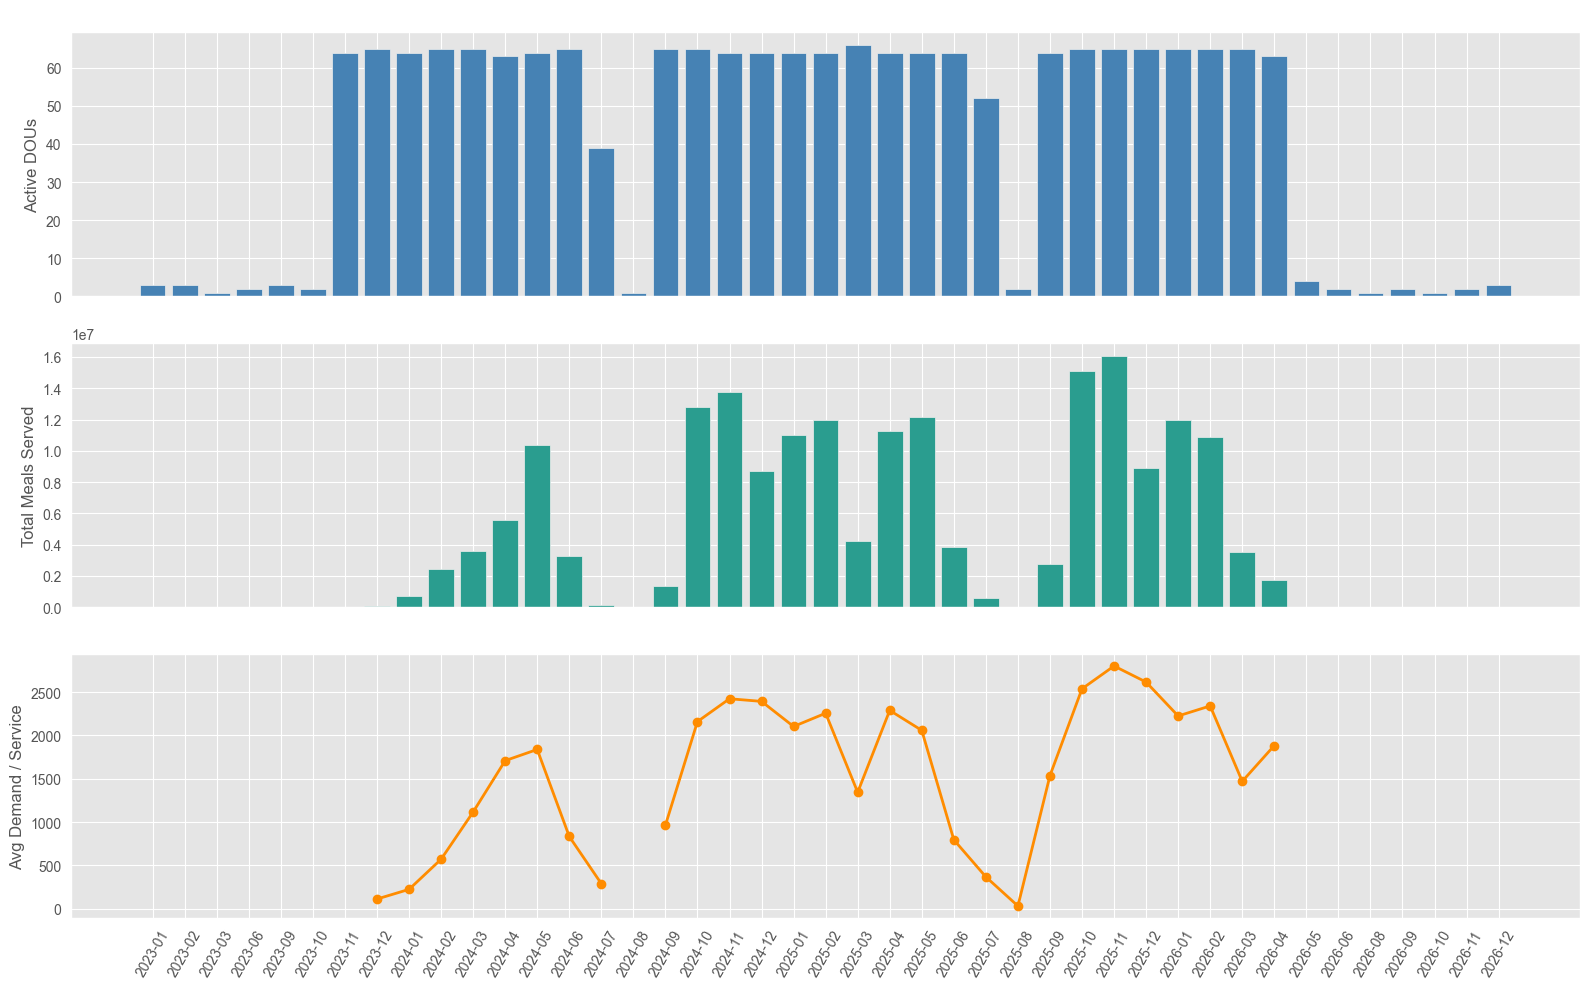

In [114]:
print(f"Date range    : {master['date'].min().date()}  →  {master['date'].max().date()}")
print(f"Calendar days : {master['date'].nunique()}")
print(f"Active DOUs   : {master['dou_code'].nunique()}")

monthly_activity = (
    master
    .assign(month=master['date'].dt.to_period('M'))
    .groupby('month', observed=True)
    .agg(
        active_dous           =('dou_code', 'nunique'),
        total_demand          =('demand',   'sum'),
        avg_demand_per_service=('demand',   'mean'),
    )
    .reset_index()
    .assign(month_str=lambda df: df['month'].astype(str))
)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].bar(monthly_activity['month_str'], monthly_activity['active_dous'],
            color='steelblue')
axes[0].set_ylabel('Active DOUs')
axes[0].set_title('Monthly Active Canteens')

axes[1].bar(monthly_activity['month_str'], monthly_activity['total_demand'],
            color='#2a9d8f')
axes[1].set_ylabel('Total Meals Served')
axes[1].set_title('Monthly Total Demand')

axes[2].plot(monthly_activity['month_str'], monthly_activity['avg_demand_per_service'],
             marker='o', color='darkorange', linewidth=2)
axes[2].set_ylabel('Avg Demand / Service')
axes[2].set_title('Monthly Average Demand per Meal Service')
axes[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('../reports/figures/01_temporal_coverage.png', dpi=150)
plt.show()

,n_service_days,avg_demand,median_demand,total_demand,avg_menu_items
meal_type,,,,,
breakfast,35834,754.41,492.00,"23,889,787.00",3.65
dinner,39974,"2,129.15","1,625.00","75,914,781.00",5.23
lunch,39729,"2,515.08","2,041.00","89,058,932.00",5.64


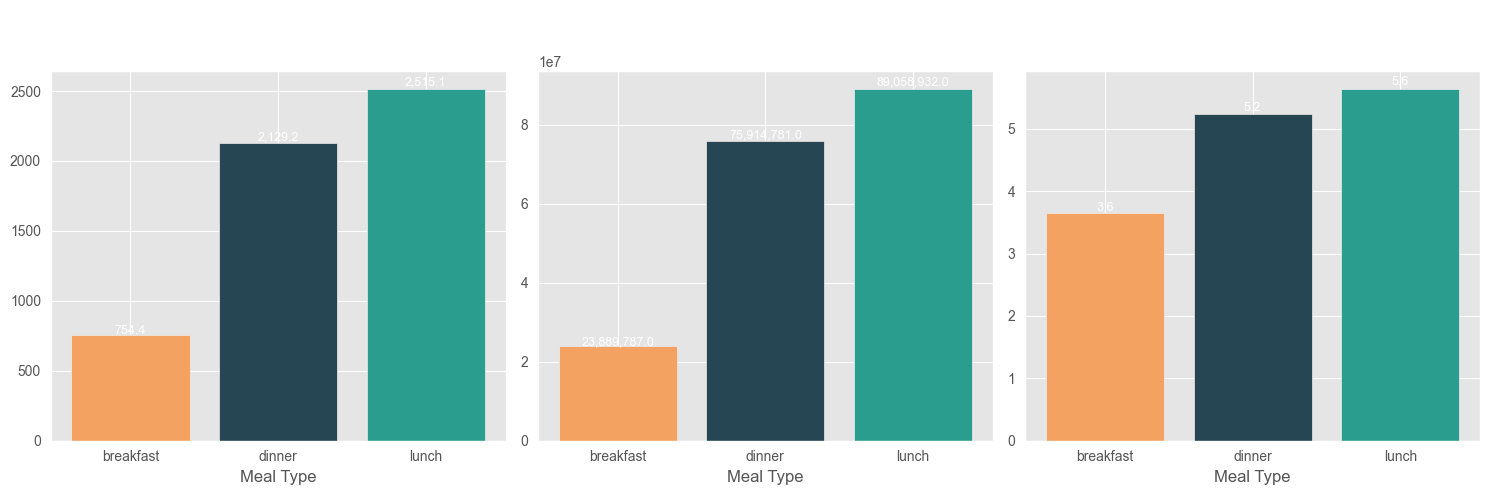

In [115]:
meal_type_stats = (
    master
    .groupby('meal_type', observed=True)
    .agg(
        n_service_days  =('date',             'count'),
        avg_demand      =('demand',           'mean'),
        median_demand   =('demand',           'median'),
        total_demand    =('demand',           'sum'),
        avg_menu_items  =('n_distinct_items', 'mean'),
    )
    .round(2)
)
display(meal_type_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (metric, ylabel) in zip(axes, [
    ('avg_demand',     'Average Demand'),
    ('total_demand',   'Total Meals Served'),
    ('avg_menu_items', 'Avg Distinct Menu Items'),
]):
    vals = meal_type_stats[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[palette.get(m, 'grey') for m in vals.index])
    ax.set_title(ylabel)
    ax.set_xlabel('Meal Type')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01, f'{v:,.1f}', ha='center', fontsize=9)

plt.suptitle('Meal Type Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_meal_type_breakdown.png', dpi=150)
plt.show()

,count,mean,std,min,25%,50%,75%,max
meal_type,,,,,,,,
breakfast,"31,667.00",754.40,797.20,0.00,122.00,492.00,"1,150.00","4,885.00"
dinner,"35,655.00","2,129.10","1,991.30",0.00,551.50,"1,625.00","3,124.00","12,158.00"
lunch,"35,410.00","2,515.10","2,074.30",0.00,845.00,"2,041.00","3,666.00","11,331.00"


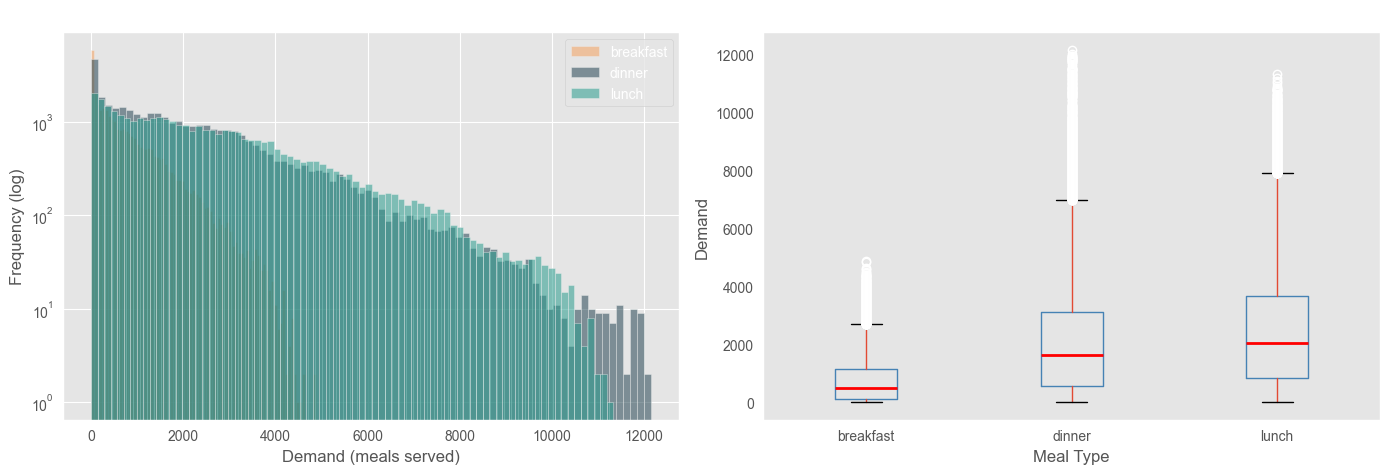


Outlier rows per meal type:


,n_outliers
meal_type,
breakfast,1043
dinner,1087
lunch,717


In [116]:
display(master.groupby('meal_type', observed=True)['demand'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for meal, grp in master.groupby('meal_type', observed=True):
    axes[0].hist(grp['demand'].dropna(), bins=80, alpha=0.55,
                 label=meal, color=palette.get(meal))
axes[0].set_xlabel('Demand (meals served)')
axes[0].set_ylabel('Frequency (log)')
axes[0].set_yscale('log')
axes[0].set_title('Demand Distribution by Meal Type')
axes[0].legend()

master.boxplot(column='demand', by='meal_type', ax=axes[1], grid=False,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Demand Spread by Meal Type')
axes[1].set_xlabel('Meal Type')
axes[1].set_ylabel('Demand')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/figures/03_demand_distribution.png', dpi=150)
plt.show()

def flag_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

master['is_demand_outlier'] = (
    master.groupby('meal_type', observed=True)['demand']
    .transform(flag_outliers_iqr)
)

print('\nOutlier rows per meal type:')
display(master.groupby('meal_type', observed=True)['is_demand_outlier']
        .sum().to_frame('n_outliers'))

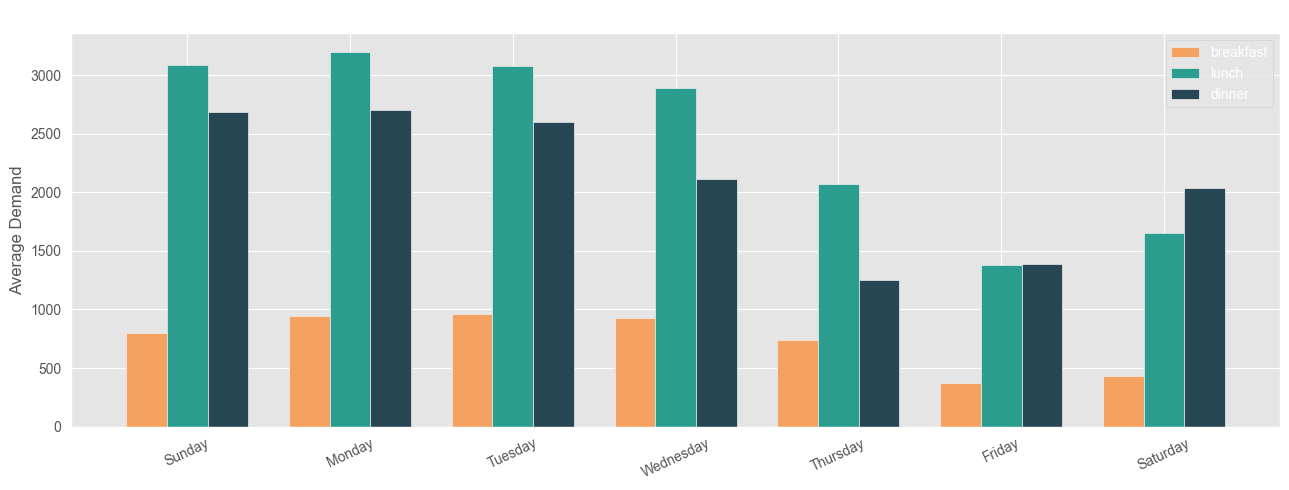

In [117]:
DOW_ORDER = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
master['dow'] = pd.Categorical(master['date'].dt.day_name(),
                               categories=DOW_ORDER, ordered=True)

dow_demand = (
    master.dropna(subset=['demand'])
    .groupby(['dow', 'meal_type'], observed=True)['demand']
    .mean()
    .reset_index()
)

days_present = [d for d in DOW_ORDER if d in dow_demand['dow'].values]
x     = np.arange(len(days_present))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, meal in enumerate(['breakfast', 'lunch', 'dinner']):
    sub  = dow_demand[dow_demand['meal_type'] == meal].set_index('dow')
    vals = [sub.loc[d, 'demand'] if d in sub.index else 0 for d in days_present]
    ax.bar(x + i * width, vals, width=width, label=meal, color=palette.get(meal))

ax.set_xticks(x + width)
ax.set_xticklabels(days_present, rotation=25)
ax.set_ylabel('Average Demand')
ax.set_title('Average Demand by Day of Week and Meal Type')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/04_dow_patterns.png', dpi=150)
plt.show()

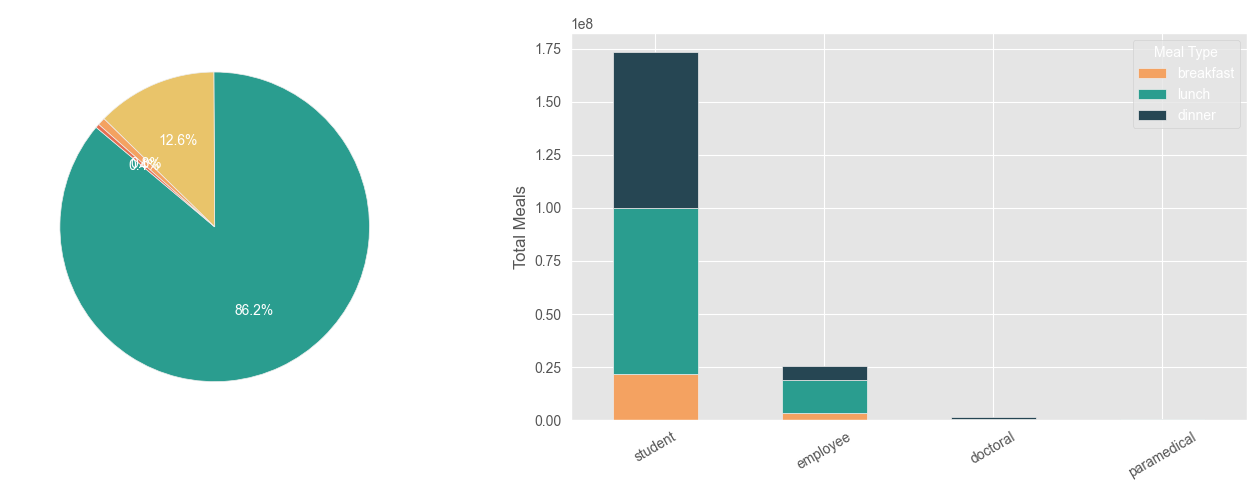

In [118]:
category_cols = {
    'student'    : ['breakfast_etudiant',    'launch_etudiant',    'dinner_etudiant'],
    'employee'   : ['breakfast_employe',     'launch_employe',     'dinner_employe'],
    'doctoral'   : ['breakfast_doctorant',   'launch_doctorant',   'dinner_doctorant'],
    'paramedical': ['breakfast_para_medical','launch_para_medical','dinner_para_medical'],
}

# Use client_dedup directly — already one row per dou×date
category_totals = {
    cat: client_dedup[cols].sum().sum()
    for cat, cols in category_cols.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    category_totals.values(), labels=category_totals.keys(),
    autopct='%1.1f%%',
    colors=['#2a9d8f','#e9c46a','#f4a261','#e76f51'],
    startangle=140,
)
axes[0].set_title('Overall Meals by Client Category')

cat_meal_df = pd.DataFrame({
    cat: {
        'breakfast': client_dedup[cols[0]].sum(),
        'lunch':     client_dedup[cols[1]].sum(),
        'dinner':    client_dedup[cols[2]].sum(),
    }
    for cat, cols in category_cols.items()
}).T

cat_meal_df.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#f4a261','#2a9d8f','#264653'])
axes[1].set_title('Meals per Client Category by Meal Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Meals')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Meal Type')

plt.tight_layout()
plt.savefig('../reports/figures/05_client_category_mix.png', dpi=150)
plt.show()

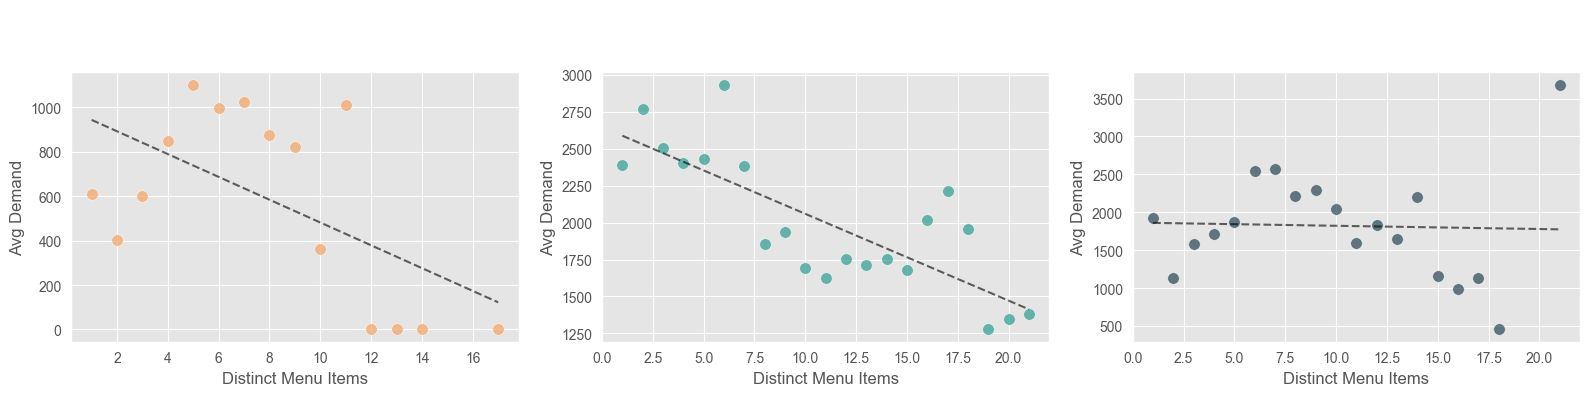

In [119]:
diversity_demand = (
    master.dropna(subset=['demand'])
    .groupby(['meal_type', 'n_distinct_items'], observed=True)['demand']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, meal in zip(axes, ['breakfast', 'lunch', 'dinner']):
    sub = diversity_demand[diversity_demand['meal_type'] == meal]
    ax.scatter(sub['n_distinct_items'], sub['demand'],
               alpha=0.7, color=palette.get(meal), s=70, edgecolors='white')
    if len(sub) > 2:
        m, b = np.polyfit(sub['n_distinct_items'], sub['demand'], 1)
        x_line = np.linspace(sub['n_distinct_items'].min(),
                             sub['n_distinct_items'].max(), 50)
        ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, alpha=0.6)
    corr = sub[['n_distinct_items', 'demand']].corr().iloc[0, 1]
    ax.set_title(f'{meal.capitalize()}  (r = {corr:.2f})')
    ax.set_xlabel('Distinct Menu Items')
    ax.set_ylabel('Avg Demand')

plt.suptitle('Menu Diversity vs Average Demand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_diversity_vs_demand.png', dpi=150)
plt.show()

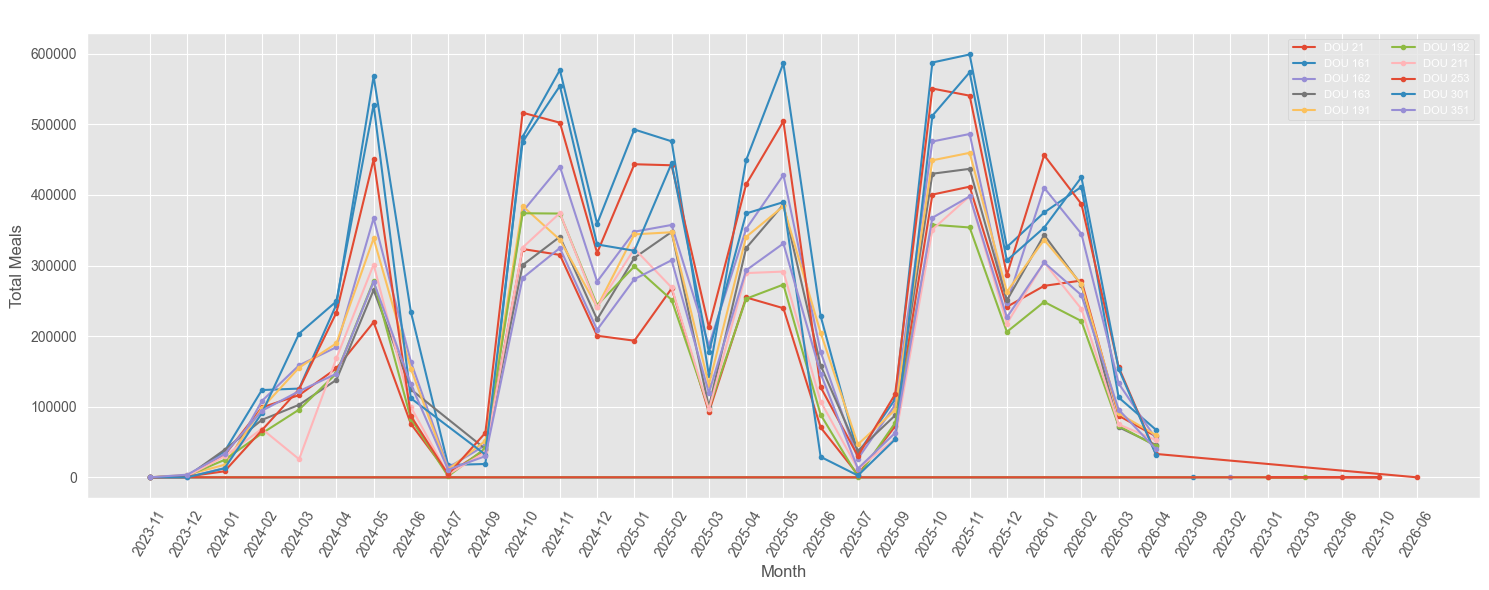

In [120]:
TOP_N    = 10
top_dous = (
    master.groupby('dou_code', observed=True)['demand']
    .sum().nlargest(TOP_N).index.tolist()
)

top_dou_monthly = (
    master[master['dou_code'].isin(top_dous)]
    .assign(month=lambda df: df['date'].dt.to_period('M'))
    .groupby(['month', 'dou_code'], observed=True)['demand']
    .sum()
    .reset_index()
    .assign(month_str=lambda df: df['month'].astype(str))
)

fig, ax = plt.subplots(figsize=(15, 6))
for dou, grp in top_dou_monthly.groupby('dou_code', observed=True):
    ax.plot(grp['month_str'], grp['demand'],
            marker='o', markersize=3, linewidth=1.5, label=f'DOU {dou}')

ax.set_title(f'Monthly Demand Trend — Top {TOP_N} Canteens by Total Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Total Meals')
ax.tick_params(axis='x', rotation=60)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../reports/figures/07_top_canteens_trend.png', dpi=150)
plt.show()

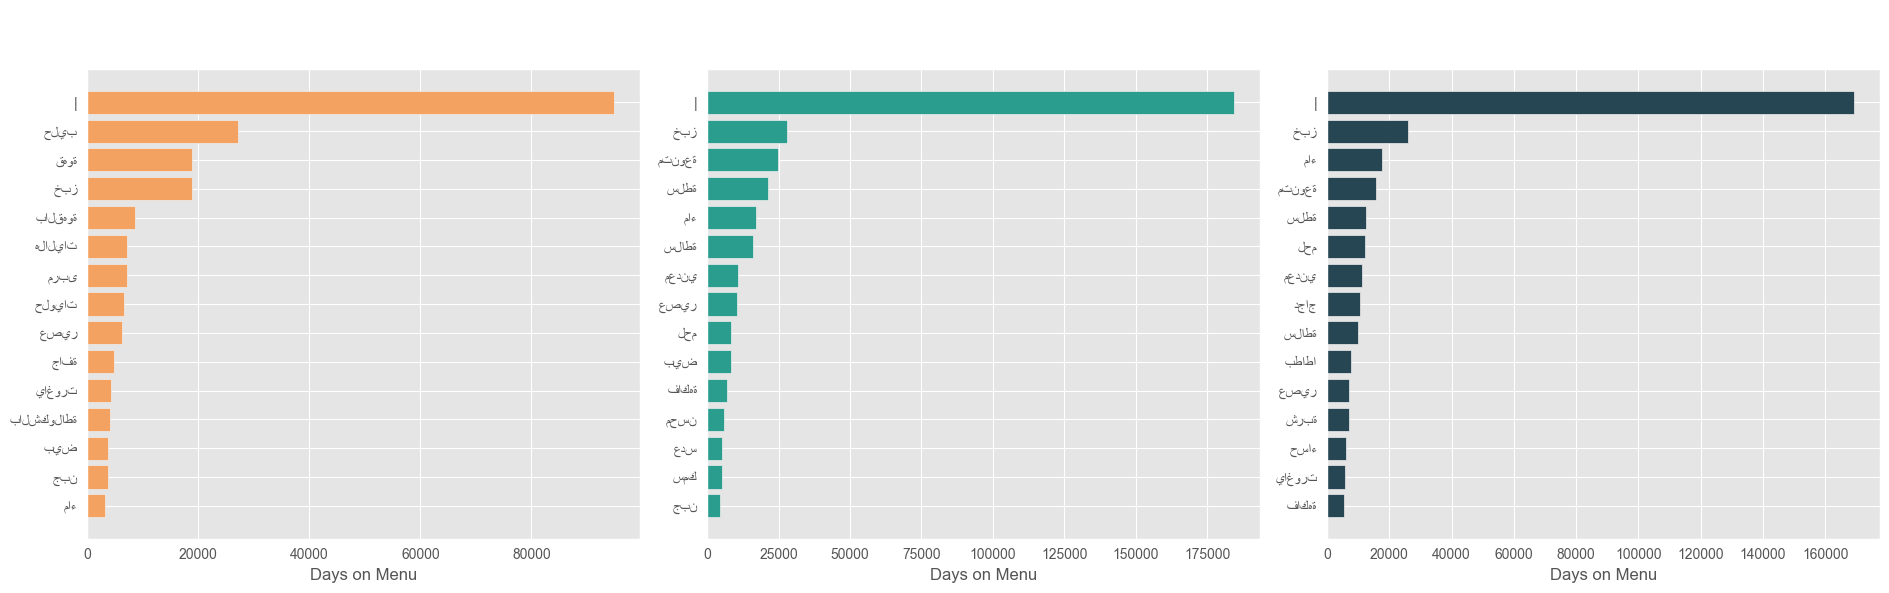

In [121]:
item_freq = (
    menu_grouped
    .assign(item=menu_grouped['meal_items'].str.split(' | '))
    .explode('item')
    .assign(item=lambda df: df['item'].str.strip())
    .groupby(['meal_type', 'item'], observed=True)
    .size()
    .reset_index(name='occurrences')
)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, meal in zip(axes, ['breakfast', 'lunch', 'dinner']):
    top_items = (
        item_freq[item_freq['meal_type'] == meal]
        .nlargest(15, 'occurrences')
        .sort_values('occurrences')
    )
    ax.barh(top_items['item'], top_items['occurrences'], color=palette.get(meal))
    ax.set_title(f'Top 15  —  {meal.capitalize()}')
    ax.set_xlabel('Days on Menu')

plt.suptitle('Most Frequently Served Menu Items', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_top_menu_items.png', dpi=150)
plt.show()

Zero-demand rows : 6,449  (5.6% of all service rows)

Zero-demand breakdown by meal type:


,n_zero,pct_of_type
meal_type,,
breakfast,3619,10.10
dinner,2686,6.70
lunch,144,0.40


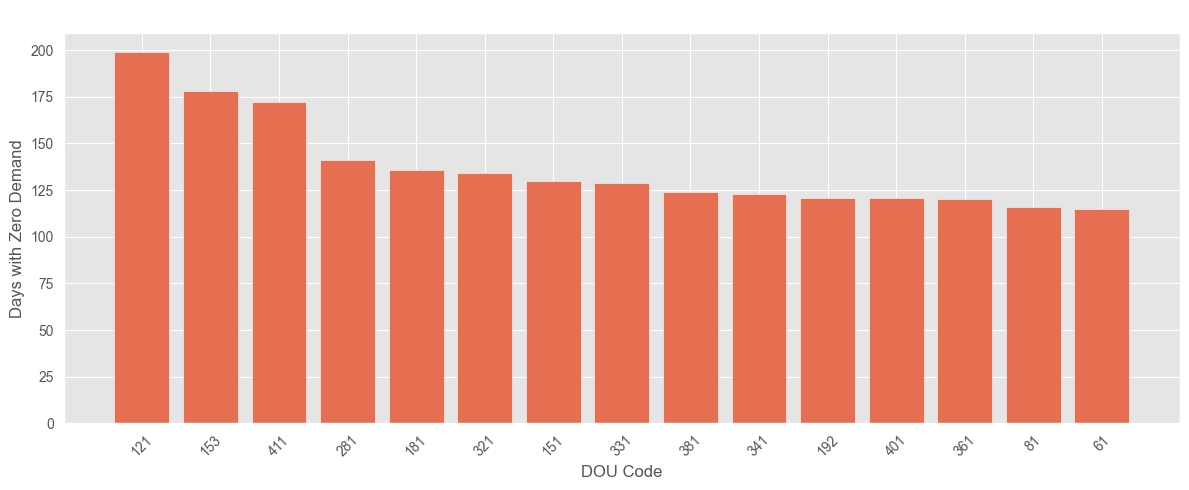

In [122]:
zero_demand = master[master['demand'] == 0]
print(f"Zero-demand rows : {len(zero_demand):,}  "
      f"({len(zero_demand)/len(master)*100:.1f}% of all service rows)")

print('\nZero-demand breakdown by meal type:')
display(
    zero_demand.groupby('meal_type', observed=True).size()
    .to_frame('n_zero')
    .assign(pct_of_type=lambda df: (
        df['n_zero'] /
        master.groupby('meal_type', observed=True).size() * 100
    ).round(1))
)

zero_by_dou = (
    master[master['demand'] == 0]
    .groupby('dou_code', observed=True).size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='zero_days')
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(zero_by_dou['dou_code'].astype(str), zero_by_dou['zero_days'],
       color='#e76f51')
ax.set_xlabel('DOU Code')
ax.set_ylabel('Days with Zero Demand')
ax.set_title('Top 15 Canteens by Zero-Demand Days')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/09_zero_demand_dous.png', dpi=150)
plt.show()

In [123]:
cat_total = sum(category_totals.values())

eda_summary = pd.DataFrame([
    {'Metric': 'Date range',
     'Value': f"{master['date'].min().date()} → {master['date'].max().date()}"},
    {'Metric': 'Calendar days covered',
     'Value': master['date'].nunique()},
    {'Metric': 'Unique DOUs (canteens)',
     'Value': master['dou_code'].nunique()},
    {'Metric': 'Meal service rows (master)',
     'Value': f"{len(master):,}"},
    {'Metric': 'Demand NaN %',
     'Value': f"{master['demand'].isna().mean()*100:.1f}%"},
    {'Metric': 'Zero-demand rows %',
     'Value': f"{(master['demand']==0).mean()*100:.1f}%"},
    {'Metric': 'Avg breakfast demand',
     'Value': f"{master.loc[master['meal_type']=='breakfast','demand'].mean():,.0f}"},
    {'Metric': 'Avg lunch demand',
     'Value': f"{master.loc[master['meal_type']=='lunch','demand'].mean():,.0f}"},
    {'Metric': 'Avg dinner demand',
     'Value': f"{master.loc[master['meal_type']=='dinner','demand'].mean():,.0f}"},
    {'Metric': 'Max single-service demand',
     'Value': f"{master['demand'].max():,.0f}"},
    {'Metric': 'Unique menu items (all types)',
     'Value': item_freq['item'].nunique()},
    {'Metric': 'IQR outlier rows',
     'Value': int(master['is_demand_outlier'].sum())},
    {'Metric': 'Student share of total meals',
     'Value': f"{category_totals['student']/cat_total*100:.1f}%"},
    {'Metric': 'Employee share of total meals',
     'Value': f"{category_totals['employee']/cat_total*100:.1f}%"},
    {'Metric': 'Doctoral share of total meals',
     'Value': f"{category_totals['doctoral']/cat_total*100:.1f}%"},
])

display(eda_summary.set_index('Metric'))
eda_summary.to_csv('../reports/eda_summary.csv', index=False)
print('✓ EDA complete. Summary saved to ../reports/eda_summary.csv')

,Value
Metric,
Date range,2023-01-08 → 2026-12-14
Calendar days covered,832
Unique DOUs (canteens),66
Meal service rows (master),"115,537"
Demand NaN %,11.1%
Zero-demand rows %,5.6%
Avg breakfast demand,754
Avg lunch demand,"2,515"
Avg dinner demand,"2,129"


✓ EDA complete. Summary saved to ../reports/eda_summary.csv
